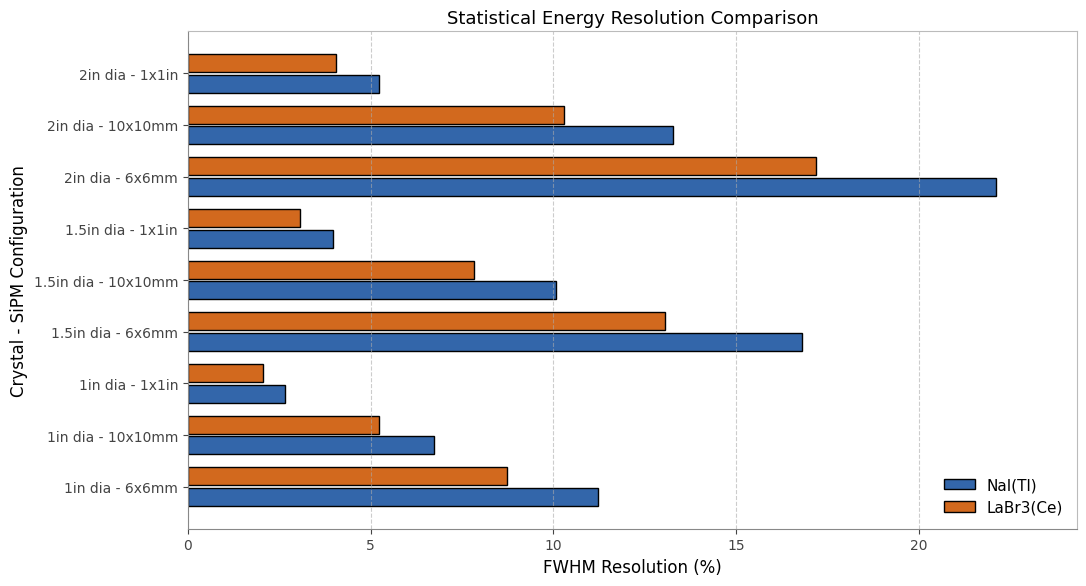


================ Statistical Resolution Results ================

Gamma energy: 0.662 MeV
SiPM PDE: 0.35
Optical efficiency: 0.7

Crystal         SiPM           Coverage     NaI(%)     LaBr3(%)   N_detected
---------------------------------------------------------------------------
1in dia         6x6mm             0.050      11.23         8.72          438
1in dia         10x10mm           0.138       6.74         5.23         1216
1in dia         1x1in             0.891       2.65         2.06         7847
1.5in dia       6x6mm             0.022      16.80        13.05          196
1.5in dia       10x10mm           0.062      10.08         7.83          543
1.5in dia       1x1in             0.398       3.97         3.08         3506
2in dia         6x6mm             0.013      22.11        17.17          113
2in dia         10x10mm           0.036      13.26        10.30          314
2in dia         1x1in             0.230       5.22         4.06         2025




In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ==============================================================
# Detector Statistical Resolution Model
# ==============================================================

import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

# Create Reports folder in same directory as notebook
REPORT_DIR = "Reports"

if not os.path.exists(REPORT_DIR):
    os.makedirs(REPORT_DIR)
    
# --------------------------------------------------------------
# Physical Parameters
# --------------------------------------------------------------

E_gamma = 0.662  # MeV (Cs-137 reference line)

# SiPM PDE (from Onsemi C-series datasheet)
# 31–41% at 420 nm → use mid value
PDE = 0.35

# Optical transport efficiency (geometry + reflector losses)
optical_efficiency = 0.7

# --------------------------------------------------------------
# Scintillator Light Yields (photons/MeV)
# --------------------------------------------------------------

scintillators = {
    "NaI(Tl)": 38000,
    "LaBr3(Ce)": 63000
}

# --------------------------------------------------------------
# Geometry
# --------------------------------------------------------------

crystal_diameters = np.array([25.4, 38.0, 50.0])  # mm
crystal_labels = ["1in dia", "1.5in dia", "2in dia"]

sipm_sizes = np.array([6.0, 10.0, 25.4])  # mm
sipm_labels = ["6x6mm", "10x10mm", "1x1in"]

# --------------------------------------------------------------
# Statistical Resolution Function
# --------------------------------------------------------------

def statistical_resolution(light_yield, E_gamma, coverage, PDE):
    N_photons = light_yield * E_gamma
    N_detected = N_photons * coverage * PDE
    sigma_rel = 1.0 / np.sqrt(N_detected)
    fwhm = 2.35 * sigma_rel * 100.0
    return fwhm

# --------------------------------------------------------------
# Compute Resolution Matrix
# --------------------------------------------------------------

num_scint = len(scintillators)
num_crystal = len(crystal_diameters)
num_sipm = len(sipm_sizes)

resolution = {}

for scint_name, light_yield in scintillators.items():
    matrix = np.zeros((num_crystal, num_sipm))
    
    for i, D in enumerate(crystal_diameters):
        crystal_area = np.pi * (D / 2.0) ** 2
        
        for j, sipm_size in enumerate(sipm_sizes):
            sipm_area = sipm_size ** 2
            coverage = (sipm_area / crystal_area) * optical_efficiency
            
            matrix[i, j] = statistical_resolution(
                light_yield,
                E_gamma,
                coverage,
                PDE
            )
    
    resolution[scint_name] = matrix

# --------------------------------------------------------------
# Horizontal Comparison Plot
# --------------------------------------------------------------

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12
})

fig, ax = plt.subplots(figsize=(11, 6))

config_labels = []
NaI_vals = []
LaBr3_vals = []

for i in range(num_crystal):
    for j in range(num_sipm):
        label = f"{crystal_labels[i]} - {sipm_labels[j]}"
        config_labels.append(label)
        
        NaI_vals.append(resolution["NaI(Tl)"][i, j])
        LaBr3_vals.append(resolution["LaBr3(Ce)"][i, j])

y = np.arange(len(config_labels))
offset = 0.2

ax.barh(y - offset, NaI_vals, height=0.35,
        color="#3366AA", edgecolor="black", label="NaI(Tl)")

ax.barh(y + offset, LaBr3_vals, height=0.35,
        color="#D2691E", edgecolor="black", label="LaBr3(Ce)")

ax.set_xlabel("FWHM Resolution (%)")
ax.set_ylabel("Crystal - SiPM Configuration")
ax.set_title("Statistical Energy Resolution Comparison")

ax.set_yticks(y)
ax.set_yticklabels(config_labels)

# Make axes gray
ax.spines["left"].set_color("#888888")
ax.spines["bottom"].set_color("#888888")
ax.spines["right"].set_color("#BBBBBB")
ax.spines["top"].set_color("#BBBBBB")

ax.tick_params(axis='x', colors='#444444')
ax.tick_params(axis='y', colors='#444444')

# Light gray grid
ax.grid(True, axis="x", linestyle="--", alpha=0.4, color="#AAAAAA")

ax.set_xlim(0, max(max(NaI_vals), max(LaBr3_vals)) * 1.1)

ax.grid(True, axis="x", linestyle="--", alpha=0.6)
ax.legend(frameon=False, loc="lower right")

plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, "ResolutionComparisonBarPlot.svg"),
            format="svg",
            bbox_inches="tight")
plt.show()

# --------------------------------------------------------------
# Print Computed Values (Audit-Friendly Table)
# --------------------------------------------------------------

print("\n================ Statistical Resolution Results ================\n")

print(f"Gamma energy: {E_gamma} MeV")
print(f"SiPM PDE: {PDE}")
print(f"Optical efficiency: {optical_efficiency}\n")

print("{:<15} {:<12} {:>10} {:>10} {:>12} {:>12}".format(
    "Crystal", "SiPM", "Coverage", "NaI(%)", "LaBr3(%)", "N_detected"
))
print("-" * 75)

for i in range(num_crystal):
    D = crystal_diameters[i]
    crystal_area = np.pi * (D / 2.0) ** 2
    
    for j in range(num_sipm):
        sipm_area = sipm_sizes[j] ** 2
        coverage = (sipm_area / crystal_area) * optical_efficiency
        
        # Photon counts
        N_photons = scintillators["NaI(Tl)"] * E_gamma
        N_detected = N_photons * coverage * PDE
        
        print("{:<15} {:<12} {:>10.3f} {:>10.2f} {:>12.2f} {:>12.0f}".format(
            crystal_labels[i],
            sipm_labels[j],
            coverage,
            resolution["NaI(Tl)"][i, j],
            resolution["LaBr3(Ce)"][i, j],
            N_detected
        ))

print("\n===============================================================\n")


